# The Secret Language of Astrophysics Plots
*An Interactive tutorial by Jayde Willingham*

Welcome! This notebook explores how astronomers use **plots as a language** to uncover patterns, compare extreme scales, and quantify uncertainty.

Rather than just reading plots, the goal here is to **understand what they’re really telling you — and why they’re designed the way they are**.

<div style="background-color:#f5f7fb; padding:20px; border-radius:10px; border-left:5px solid #4a90e2;">

## What You’ll Learn

This notebook walks through three core ideas that appear everywhere in astrophysics:

### 1. Logarithmic Thinking: Planetary Spacing
**Titius–Bode Law**
- Why planetary distances follow an approximately exponential pattern  
- How taking the logarithm reveals a hidden linear trend  
- Why log scales are essential when dealing with large dynamic ranges  

→ Key idea: *Log scales turn “messy curves” into simple, interpretable lines.*


### 2. Number Density & Scaling
**Stellar Mass Function (SMF)**
- What φ(M) actually represents (galaxies per unit volume)  
- Why astronomers use **dex⁻¹** instead of linear units  
- How combining log axes with dex scaling preserves physical meaning  

→ Key idea: *Good axis choices don’t just look nicer — they make the physics clearer.*


### 3. Uncertainty & Model Constraints
**Exoplanet Radial Velocity & Confidence Contours**
- How we infer unseen planets from stellar motion  
- What a **chi-squared grid** is really measuring  
- How confidence contours show which parameters fit the data  

→ Key idea: *Contours aren’t just shapes — they map out what the data allows.*


## What You’ll Do

Each section includes:
- A **minimal working example** (code + plot)
- A clear explanation of the physics
- Parameters you can tweak to see effects in real time

Try experimenting with:
- Changing scales (linear vs log)
- Adjusting model parameters
- Increasing noise or sample size
- Zooming parameter ranges



## Tip

Don’t just run the notebook — *play with it*.  
Small changes to parameters can completely reshape what you see, and that’s where the real intuition comes from.
</div>

## Titius–Bode Law and Planetary Spacing

The **Titius–Bode law** is a historical empirical relation that attempts to describe the spacing of planets in the Solar System. In its common form, it predicts the semi-major axis $(a$) (in astronomical units, AU) as

$a = 0.4 + 0.3 \times 2^k$

where $(k = -1, 0, 1, 2, \dots)$

Despite its simplicity, this relation reproduces the approximate positions of several planets and even anticipated the location of the asteroid belt, where Ceres was later discovered. However, it is not a true physical law: it lacks a firm theoretical basis and notably breaks down for Neptune.


## Why plot this in log space?

The Titius–Bode relation is inherently **exponential**: orbital distances increase roughly as powers of 2. This means planetary spacing follows a *multiplicative* pattern rather than an additive one.

Taking the logarithm transforms this exponential behaviour into a **linear relationship**:

$\log_{10}(a) \propto k$

As a result, when $(\log_{10}(a)$) is plotted against planet index, the data align approximately along a straight line.

## Why this matters

Using logarithmic units is essential for revealing the structure of the relation:

- It exposes the **underlying regularity** in planetary spacing  
- It converts multiplicative growth into a **linear trend**  
- It allows inner and outer planets—spanning orders of magnitude in distance—to be compared on the same scale  

Without a logarithmic transformation, the inner planets would appear compressed near the origin while the outer planets dominate the axis, obscuring any pattern.


In this sense, the logarithmic scale does more than improve visual clarity—it highlights the fundamental feature that makes the Titius–Bode relation noteworthy.

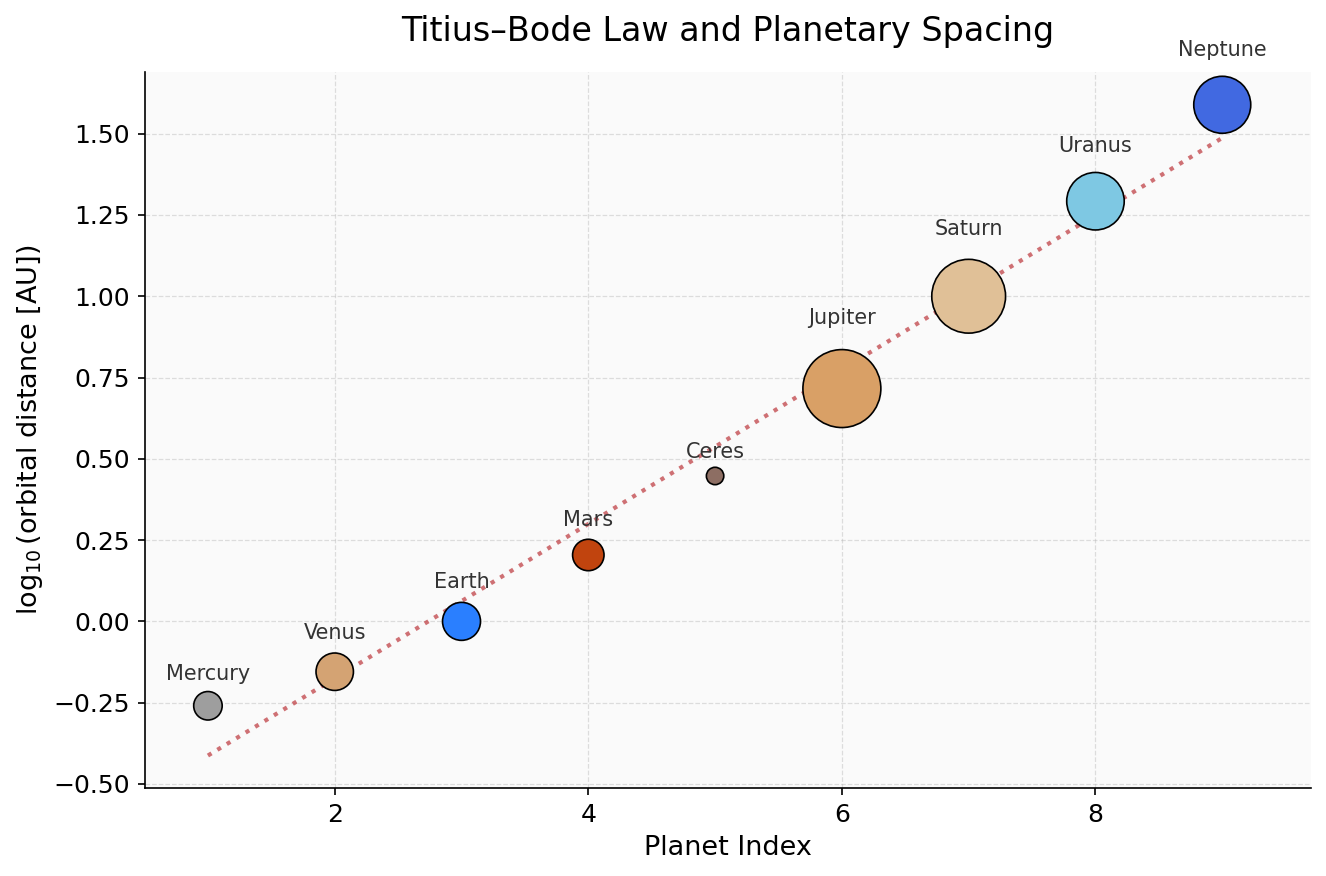

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# DATA SETUP
# =====================================================

# Names of Solar System objects (including Ceres in the asteroid belt)
labels = ["Mercury", "Venus", "Earth", "Mars", "Ceres", "Jupiter", "Saturn", "Uranus", "Neptune"]

# Index for plotting (just 1, 2, 3, ...)
n = np.arange(1, len(labels) + 1)

# Titius–Bode index (controls spacing)
k = np.array([-1, 0, 1, 2, 3, 4, 5, 6, 7])

# -----------------------------------------------------
# TRY THIS:
# Change values in k (e.g. remove Neptune or extend further)
# and see how the spacing pattern changes
# -----------------------------------------------------


# =====================================================
#  TITIUS–BODE RELATION
# =====================================================

# Orbital distances (AU)
a = 0.4 + 0.3 * (2.0 ** k)

# Logarithmic version (this is the key transformation!)
log_a = np.log10(a)

# -----------------------------------------------------
# 🔍 TRY THIS (IMPORTANT):
# 1. Replace log_a with just 'a' in the plot below
# 2. Change the y-axis label accordingly
# → What happens to the pattern?
# → Do the points still look like a straight line?
#
# This demonstrates WHY we use log scaling!
# -----------------------------------------------------


# =====================================================
# VISUAL PROPERTIES
# =====================================================

# Planet radii (km) → used to scale marker sizes
radii_km = np.array([2440, 6052, 6371, 3390, 473, 69911, 58232, 25362, 24622])

# Compress size differences so Jupiter doesn’t dominate too much
sizes = (radii_km / radii_km.max())**0.6 * 1400

# -----------------------------------------------------
# TRY THIS:
# Change the exponent (0.6 → 1.0 or 0.3)
# → How does this affect how “fair” the sizes look?
# -----------------------------------------------------

# Approximate colours for planets
colors = ["#9e9e9e", "#d4a373", "#2a7fff", "#c1440e", "#8d6e63", "#d9a066", "#e0c097", "#7ec8e3", "#4169e1"]


# =====================================================
# 📈 LINEAR FIT (in log space!)
# =====================================================

# Fit a straight line to the log data
coeffs = np.polyfit(n, log_a, 1)
fit_line = np.poly1d(coeffs)

# -----------------------------------------------------
# 🔍 THINK ABOUT THIS:
# Why are we fitting a straight line to log_a instead of a?
# What does a straight line here actually represent physically?
# -----------------------------------------------------


# =====================================================
# 🎨 PLOTTING
# =====================================================

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "figure.dpi": 150,
    "savefig.dpi": 300
})

fig, ax = plt.subplots(figsize=(9, 6))

# Background styling
ax.set_facecolor("#fafafa")

ax.scatter(
    n, log_a,   # 👈 CHANGE THIS TO 'a' to explore linear vs log
    s=sizes,
    c=colors,
    edgecolor="black",
    linewidth=0.8,
    zorder=3
)

# Best-fit line
ax.plot(n, fit_line(n), linestyle=":", linewidth=2, color="#c44e52", alpha=0.8)


# =====================================================
# LABELS
# =====================================================

marker_radius_pts = np.sqrt(sizes)
y_scale = 0.005  # controls how far labels sit above points

# -----------------------------------------------------
#  TRY THIS:
# Increase y_scale if labels overlap
# -----------------------------------------------------

for i, txt in enumerate(labels):
    dy = y_scale * marker_radius_pts[i]

    ax.text(
        n[i],
        log_a[i] + dy,   # 👈 also change to 'a[i]' if using linear scale
        txt,
        fontsize=10,
        color="#333333",
        ha='center',
        va='bottom'
    )


# =====================================================
# AXES & INTERPRETATION
# =====================================================

ax.set_title("Titius–Bode Law and Planetary Spacing", pad=15)

ax.set_xlabel("Planet Index")

ax.set_ylabel(r"$\log_{10}(\mathrm{orbital\ distance\ [AU]})$")

# -----------------------------------------------------
# 🔍 TRY THIS (CRUCIAL):
# If you switch to linear (a instead of log_a), update to:
# ax.set_ylabel("Orbital distance [AU]")
#
# Compare BOTH versions side-by-side if you can!
# -----------------------------------------------------


# Grid and styling
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlim(0.5, len(labels) + 0.7)

plt.tight_layout()

# -----------------------------------------------------
# OPTIONAL
# -----------------------------------------------------
# plt.savefig("titius_bode_plot.png", bbox_inches="tight")

plt.show()


# =====================================================
# 🚀 FINAL CHALLENGE
# =====================================================
# 1. Plot BOTH versions (linear and log) in two subplots
# 2. Which one makes the pattern clearer?
# 3. Why does log scaling turn a curve into a straight line?
#
# This is a key idea used everywhere in astrophysics!
# =====================================================

# What is a Stellar Mass Function?

The **stellar mass function (SMF)** describes how many galaxies exist per unit volume as a function of their stellar mass. It is usually written as **φ(M)**, where φ (phi) represents the **number density of galaxies per unit volume** at a given stellar mass M. In other words, φ tells us how many galaxies of a certain mass exist in a cubic megaparsec (or other volume unit).

Because galaxy masses span many orders of magnitude, the y-axis is often expressed in **dex⁻¹**, which means "per logarithmic interval of mass." Using dex⁻¹ ensures that φ(M) represents the **number of galaxies per unit volume per logarithmic mass interval**. This makes it easier to compare the relative abundance of low- and high-mass galaxies on the same plot, and the slope of the SMF becomes more interpretable.

If we used a **linear mass interval** instead of dex⁻¹, the high-mass end would be visually compressed and underrepresented, while the low-mass end would dominate. Using a purely **logarithmic axis without dex⁻¹** would show the mass range clearly, but φ would no longer reflect the number density per log mass interval. By combining a **logarithmic mass axis with dex⁻¹ scaling**, we can both visualize the full mass range and retain physically meaningful units for number density.

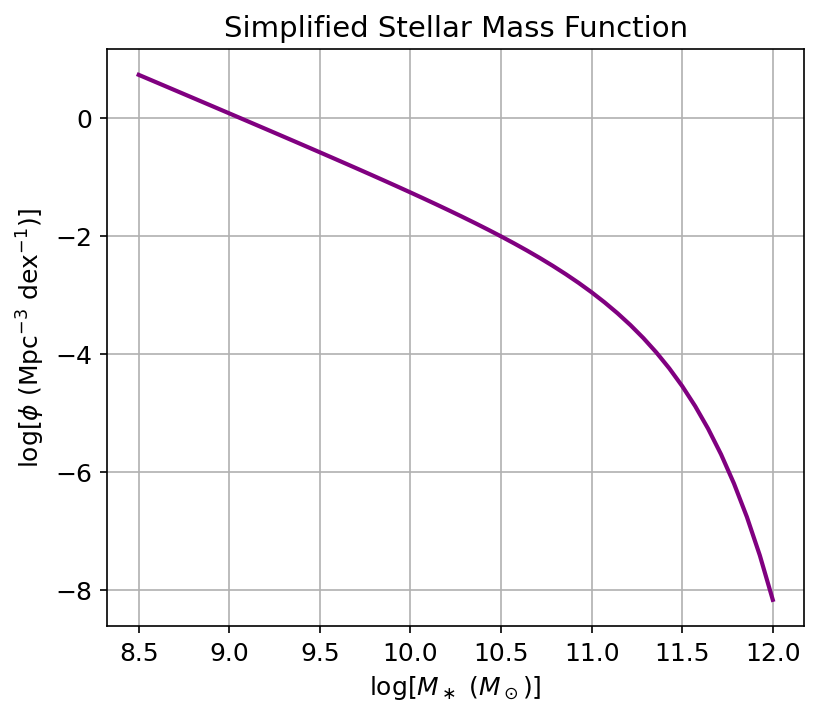

In [17]:
# -----------------------------
# Simple Stellar Mass Function Example
# -----------------------------

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Define the mass range
# -----------------------------
# logM is the logarithm (base 10) of stellar mass in solar masses (M_sun)
# Using log scale helps us see both low-mass and high-mass galaxies clearly
logM = np.linspace(8.5, 12, 50)  # 50 points from 10^8.5 to 10^12 M_sun

# -----------------------------
# Step 2: Define the Schechter function parameters
# -----------------------------
# phi_star: overall number density of galaxies (normalization)
# M_star: characteristic "knee" mass where the function starts to drop off
# alpha: slope for low-mass galaxies (negative means more low-mass galaxies)
phi_star = 0.003  # in Mpc^-3 dex^-1
M_star = 1e11     # in solar masses
alpha = -1.3      # typical value from observations

# -----------------------------
# Step 3: Convert from log mass to linear mass
# -----------------------------
# Most formulas for the Schechter function use linear mass, not log
M = 10**logM

# -----------------------------
# Step 4: Compute the Stellar Mass Function
# -----------------------------
# phi(M) = phi_star * (M/M_star)^alpha * exp(-M/M_star)
# This gives the number density of galaxies per unit volume per dex of mass
phi = phi_star * (M / M_star)**alpha * np.exp(-M / M_star)

# -----------------------------
# Step 5: Plot the result
# -----------------------------
plt.figure(figsize=(6,5))
# Plot log(phi) vs log(M) so we can see the full range of values clearly
plt.plot(logM, np.log10(phi), lw=2, color='purple')

# Labels using LaTeX formatting for clarity
plt.xlabel(r'$\log[M_\ast\ (M_\odot)]$', fontsize=12)
plt.ylabel(r'$\log[\phi\ (\mathrm{Mpc}^{-3}\ \mathrm{dex}^{-1})]$', fontsize=12)
plt.title('Simplified Stellar Mass Function', fontsize=14)
plt.grid(True)
plt.show()

# -----------------------------
# Suggested Experiments for Students
# -----------------------------
# 1. Change alpha to see how the low-mass slope affects the number of small galaxies.
# 2. Change M_star to shift the "knee" in the distribution.
# 3. Change phi_star to see the effect on overall galaxy density.
# 4. Try plotting phi vs. M (linear scale) to see why log scaling is often preferred.
# 5. Increase the number of points in logM to make the curve smoother.

# Exploring Confidence Contours with Exoplanet Radial Velocity

In this example, we are generating a **mock radial velocity (RV) dataset** for a star being orbited by a single planet. The left panel shows the **RV light curve** with simulated measurements (points) and the **best-fit model** (red line). The right panel shows the **confidence contours** for two model parameters:

- **Orbital period (P)** — how long the planet takes to orbit the star.
- **Semi-amplitude (K)** — the size of the star's velocity wobble caused by the planet.

## What are the contours?

The contours are derived from a **chi-squared grid** that measures how well different combinations of K and P fit the data. Each contour level corresponds to a common **confidence interval**:

- **68%** confidence (blue) — roughly a 1σ region
- **95%** confidence (green) — roughly a 2σ region
- **99%** confidence (red) — roughly a 3σ region

Points inside a contour are consistent with the data at the given confidence level. The black "x" marks the **best-fit parameters**.

## How to play with this

You can try changing:

1. **Noise level (`sigma`)** — higher noise widens the contours; lower noise makes them tighter.
2. **Number of observations (`t`)** — more data points generally reduce uncertainties.
3. **Time baseline** — observing over more orbital cycles gives better constraints on P.
4. **Initial guesses or parameter ranges** — to see how the grid and contour zoom affect the visualization.

By experimenting with these, you can **see directly how measurement quality and sampling affect the precision of parameter estimates** in astronomy.

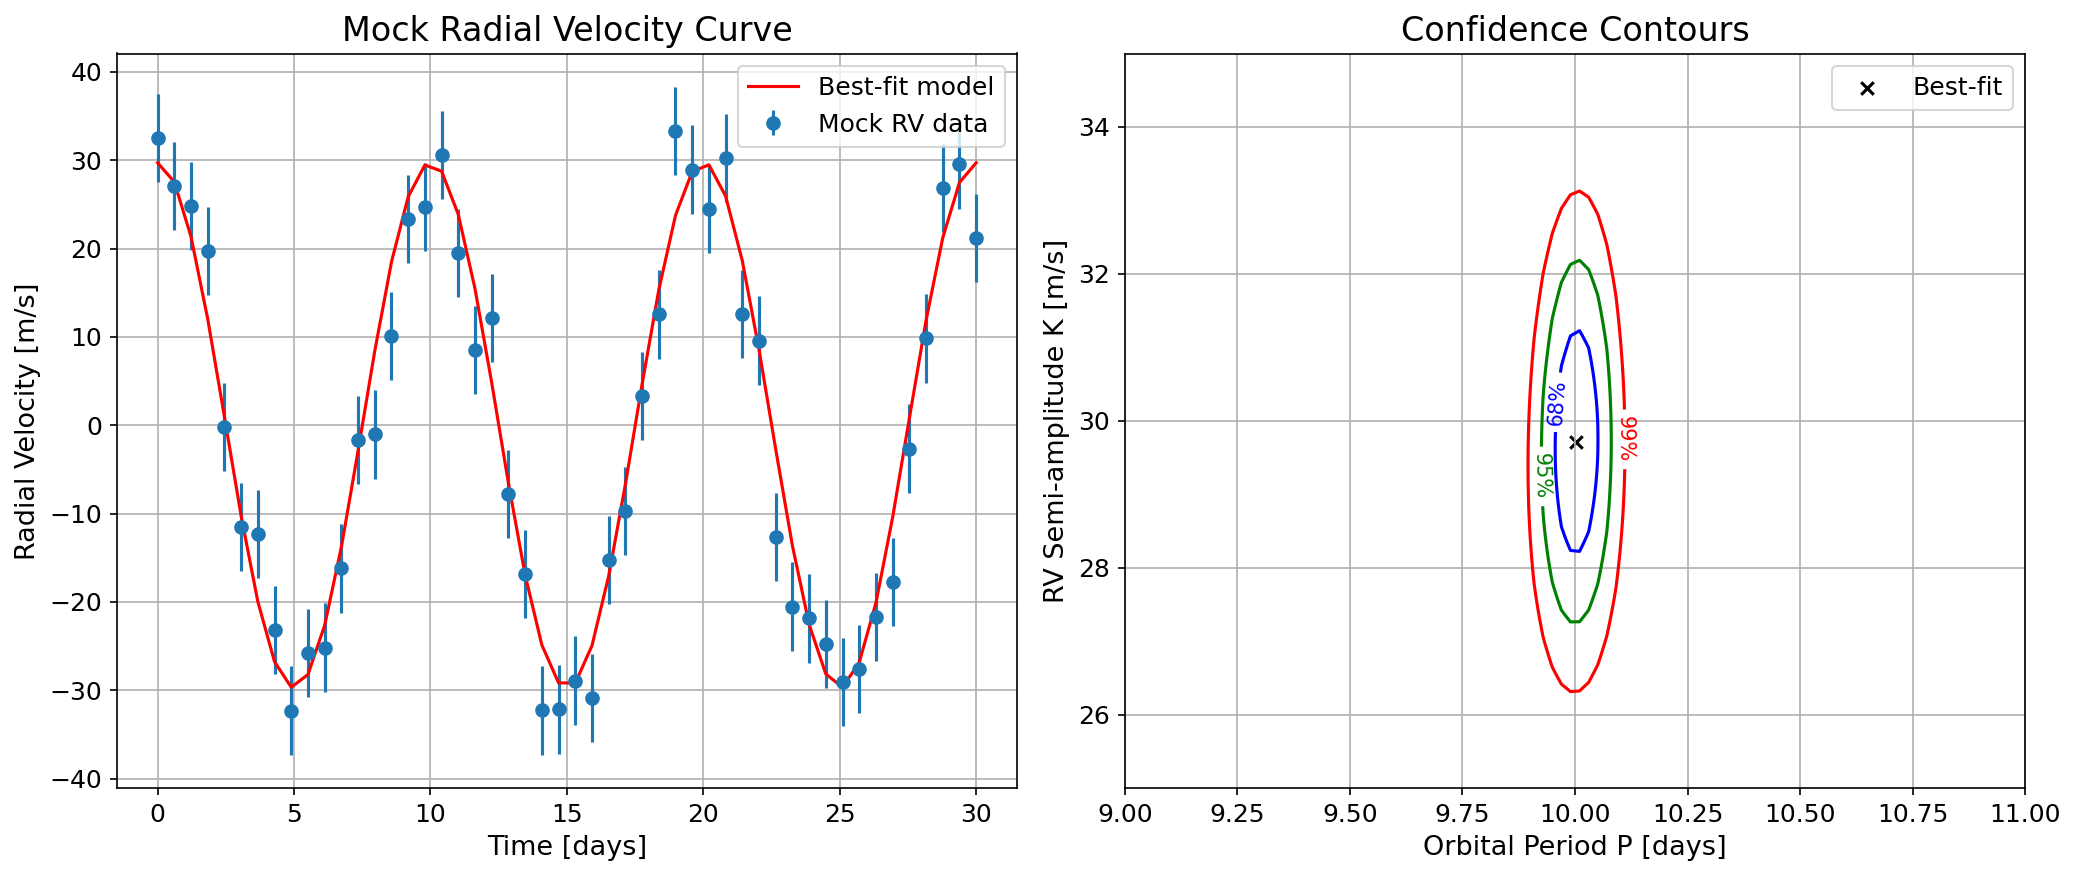

In [28]:
# -----------------------------
# RV Light Curve and Confidence Contours Tutorial
# -----------------------------
# Left: mock radial velocity (RV) data with best-fit model
# Right: confidence contours in K vs P parameter space
# This shows how well the model parameters are constrained

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# -----------------------------
# 1. Generate synthetic data
# -----------------------------
# True parameters of our "planet"
K_true = 30      # RV semi-amplitude in m/s
P_true = 10      # Orbital period in days
t0_true = 0      # Reference time
gamma_true = 0   # Systemic velocity
sigma = 5        # Measurement uncertainty (noise level)

# Observation times (days)
t = np.linspace(0, 30, 50)  # 50 evenly spaced points

# Radial velocity model: simple sinusoid
def rv_model(t, K, P):
    return K * np.cos(2 * np.pi * (t - t0_true) / P) + gamma_true

# Add Gaussian noise to mimic real observations
np.random.seed(42)  # for reproducibility
v_obs = rv_model(t, K_true, P_true) + np.random.normal(0, sigma, len(t))

# -----------------------------
# 2. Fit the model to the data
# -----------------------------
# curve_fit tries to find the best K and P that match the observed RVs
popt, pcov = curve_fit(rv_model, t, v_obs, p0=[25, 9])
K_fit, P_fit = popt  # best-fit parameters

# -----------------------------
# 3. Compute chi-squared grid for confidence contours
# -----------------------------
# Create a grid of K and P values around the best-fit to explore parameter space
K_vals = np.linspace(25, 35, 100)  # zoomed in around best-fit
P_vals = np.linspace(9, 11, 100)   # zoomed in around best-fit
chi2_grid = np.zeros((len(K_vals), len(P_vals)))

# Loop over all grid points to compute chi-squared
for i, K in enumerate(K_vals):
    for j, P in enumerate(P_vals):
        model = rv_model(t, K, P)
        chi2_grid[i, j] = np.sum((v_obs - model)**2 / sigma**2)

# -----------------------------
# 4. Define confidence levels
# -----------------------------
# For two parameters, Delta chi2 = [2.3, 6.17, 11.8] corresponds to 68%, 95%, 99%
levels = [2.3, 6.17, 11.8]

# -----------------------------
# 5. Side-by-side plots
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Left: RV light curve
axes[0].errorbar(t, v_obs, yerr=sigma, fmt='o', label='Mock RV data')
axes[0].plot(t, rv_model(t, K_fit, P_fit), label='Best-fit model', color='red')
axes[0].set_xlabel('Time [days]')
axes[0].set_ylabel('Radial Velocity [m/s]')
axes[0].set_title('Mock Radial Velocity Curve')
axes[0].legend()
axes[0].grid(True)

# Right: Confidence contours
# We add chi2_grid.min() so contours are relative to the minimum chi-squared
cs = axes[1].contour(P_vals, K_vals, chi2_grid, levels=np.array(levels)+chi2_grid.min(),
                     colors=['blue','green','red'])
# Label the contours with percentages
axes[1].clabel(cs, inline=True, fontsize=10, fmt={cs.levels[0]:'68%', cs.levels[1]:'95%', cs.levels[2]:'99%'})
axes[1].scatter(P_fit, K_fit, color='black', marker='x', label='Best-fit')
axes[1].set_xlabel('Orbital Period P [days]')
axes[1].set_ylabel('RV Semi-amplitude K [m/s]')
axes[1].set_title('Confidence Contours')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# -----------------------------
# Suggested Experiments for Students
# -----------------------------
# 1. Change K_true, P_true, or sigma to see how the contours widen or shrink.
# 2. Try different initial guesses in curve_fit to see if it converges to the correct solution.
# 3. Increase the number of observations (len(t)) to see how more data tightens the contours.
# 4. Change the contour levels or explore 1-sigma vs 2-sigma regions.
# 5. Plot chi2_grid as a heatmap to visualize the "valley" of best-fit parameters.